## GAN for Faces
#### Basically, we are using Deep Convolutional Generative Adversial Network (DCGAN) for the generation of the faces with light weight dataset collected from our classroom.

In [22]:
import os
import torch
import pandas as pd
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid, save_image
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from tqdm import tqdm
import matplotlib.pyplot as plt

In [5]:
# Hyperparameters 
batch_size = 32
image_size = 64
latent_dim = 100
lr = 0.0002
num_epochs = 300
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
# Transforms 
transform = transforms.Compose([
    transforms.Grayscale(),                      # Convert to grayscale
    transforms.Resize((64, 64)),                 # Resize           
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),          # [-1, 1]
])

In [7]:
dataset = ImageFolder(root='./dataset', transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

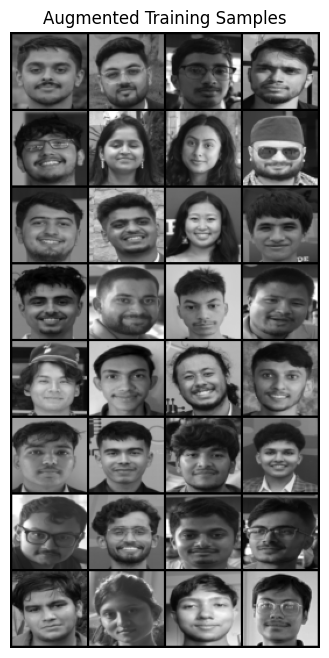

In [8]:
# Get a batch of augmented images
data_iter = iter(dataloader)
images, _ = next(data_iter)

# Make grid and display
grid_img = make_grid(images, nrow=4, normalize=True)

plt.figure(figsize=(8, 8))
plt.imshow(grid_img.permute(1, 2, 0))  # Convert from CHW to HWC
plt.title("Augmented Training Samples")
plt.axis('off')
plt.show()

In [9]:
# Generator 
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

In [10]:
# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)

In [11]:
# Initialize Models 
G = Generator().to(device)
D = Discriminator().to(device)

In [12]:
# Loss and Optimizers 
criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

In [13]:
# Training 
fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

In [14]:
# training loop
train_losses_D = []
train_losses_G = []

for epoch in range(num_epochs):
    loop = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch [{epoch+1}/{num_epochs}]")
    
    loss_D_epoch = 0.0
    loss_G_epoch = 0.0

    for batch_idx, (real_imgs, _) in loop:
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # Train Discriminator 
        optimizer_D.zero_grad()

        # Real images
        real_labels = torch.ones(b_size, device=device)
        output_real = D(real_imgs).view(-1)
        loss_real = criterion(output_real, real_labels)

        # Fake images
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake_imgs = G(noise)
        fake_labels = torch.zeros(b_size, device=device)
        output_fake = D(fake_imgs.detach()).view(-1)
        loss_fake = criterion(output_fake, fake_labels)

        # Total Discriminator Loss
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        ### === Train Generator === ###
        optimizer_G.zero_grad()

        fake_labels = torch.ones(b_size, device=device)  # Generator wants D to believe fakes are real
        output = D(fake_imgs).view(-1)
        loss_G = criterion(output, fake_labels)
        loss_G.backward()
        optimizer_G.step()

        # Logging
        loss_D_epoch += loss_D.item()
        loss_G_epoch += loss_G.item()

        loop.set_postfix(loss_D=loss_D.item(), loss_G=loss_G.item())

    avg_loss_D = loss_D_epoch / len(dataloader)
    avg_loss_G = loss_G_epoch / len(dataloader)

    print(f"Epoch {epoch+1} | Discriminator Loss: {avg_loss_D:.4f} | Generator Loss: {avg_loss_G:.4f}", end='\r')

    train_losses_D.append(avg_loss_D)
    train_losses_G.append(avg_loss_G)

    # (Optional) Save generated images for visual tracking
    with torch.no_grad():
        fake = G(fixed_noise).detach().cpu()
        save_image(fake, f"outputs/fake_epoch_{epoch+1}.png", normalize=True)


Epoch [1/300]: 100%|██████████| 2/2 [00:01<00:00,  1.32it/s, loss_D=1.22, loss_G=3.99]


Epoch [2/300]: 100%|██████████| 2/2 [00:01<00:00,  1.69it/s, loss_D=0.402, loss_G=4.57]


Epoch [3/300]: 100%|██████████| 2/2 [00:01<00:00,  1.86it/s, loss_D=0.273, loss_G=5.49]


Epoch [4/300]: 100%|██████████| 2/2 [00:01<00:00,  1.73it/s, loss_D=0.286, loss_G=5.83]


Epoch [5/300]: 100%|██████████| 2/2 [00:01<00:00,  1.75it/s, loss_D=0.181, loss_G=6.17]


...

Epoch [296/300]: 100%|██████████| 2/2 [00:00<00:00,  2.06it/s, loss_D=0.0382, loss_G=5.68]


Epoch [297/300]: 100%|██████████| 2/2 [00:01<00:00,  1.95it/s, loss_D=0.0688, loss_G=4.8] 


Epoch [298/300]: 100%|██████████| 2/2 [00:00<00:00,  2.01it/s, loss_D=0.101, loss_G=5.54] 


Epoch [299/300]: 100%|██████████| 2/2 [00:01<00:00,  1.97it/s, loss_D=0.107, loss_G=5.1]  


Epoch [300/300]: 100%|██████████| 2/2 [00:01<00:00,  1.92it/s, loss_D=0.0713, loss_G=4.83]

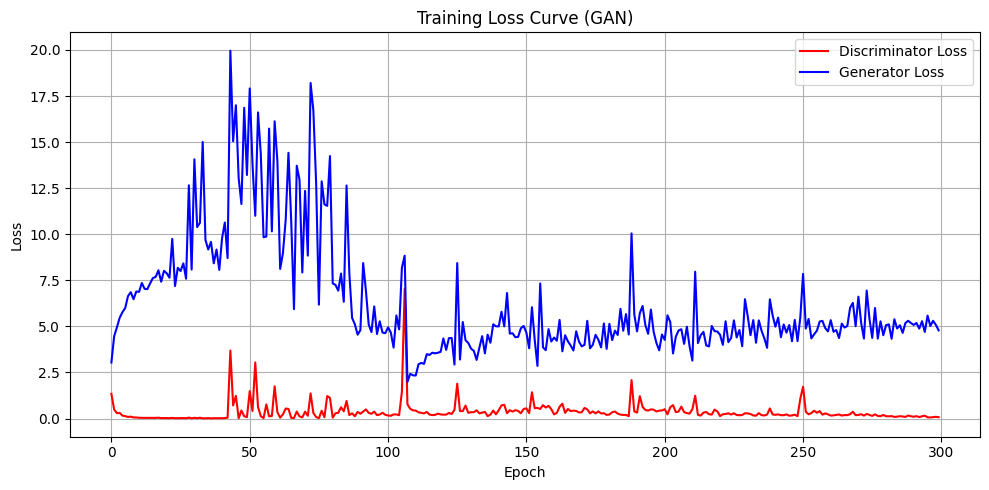

In [15]:
# Make sure train_losses_G and train_losses_D are already populated

plt.figure(figsize=(10, 5))
plt.plot(train_losses_D, label='Discriminator Loss', color='red')
plt.plot(train_losses_G, label='Generator Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve (GAN)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
# Instantiate FID metric
fid = FrechetInceptionDistance(feature=2048).to(device)

# Resize transform (no normalization!)
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.CenterCrop(299),
])

# Helper to convert grayscale 1-channel tensor to 3-channel RGB by repeating channels
def gray_to_rgb(imgs):
    if imgs.shape[1] == 1:
        return imgs.repeat(1, 3, 1, 1)
    return imgs

# 1. Update FID with real images
for real_imgs, _ in dataloader:  # your real image dataloader
    real_imgs = transform(real_imgs).to(device)
    real_imgs = gray_to_rgb(real_imgs)

    # Convert to uint8 as expected by FID (0-255)
    if real_imgs.dtype != torch.uint8:
        real_imgs = (real_imgs * 255).clamp(0, 255).to(torch.uint8)

    fid.update(real_imgs, real=True)
    break  # remove break to use whole dataset

# 2. Update FID with fake images generated by your GAN
G.eval()
with torch.no_grad():
    z = torch.randn(64, latent_dim, 1, 1, device=device)
    fake_imgs = G(z)
    fake_imgs = gray_to_rgb(fake_imgs)
    fake_imgs = transform(fake_imgs)

    if fake_imgs.dtype != torch.uint8:
        fake_imgs = (fake_imgs * 255).clamp(0, 255).to(torch.uint8)

    fid.update(fake_imgs, real=False)

# 3. Compute final FID score
fid_score = fid.compute()
print(f"FID Score: {fid_score.item():.4f}")

FID Score: 324.8424


In [20]:
# Instantiate metric
is_metric = InceptionScore().to(device)

# Resize transform (no normalization)
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.CenterCrop(299),
])

def gray_to_rgb(imgs):
    if imgs.shape[1] == 1:
        return imgs.repeat(1, 3, 1, 1)
    return imgs

G.eval()
with torch.no_grad():
    z = torch.randn(64, latent_dim, 1, 1, device=device)
    fake_imgs = G(z)  # shape [B,1,H,W] assumed
    
    fake_imgs = gray_to_rgb(fake_imgs)
    fake_imgs = transform(fake_imgs)
    
    # Convert float [0,1] to uint8 [0,255]
    if fake_imgs.dtype != torch.uint8:
        fake_imgs = (fake_imgs * 255).clamp(0, 255).to(torch.uint8)
    
    is_metric.update(fake_imgs)

inception_score = is_metric.compute()
print(f"Inception Score: {inception_score[0].item():.4f} ± {inception_score[1].item():.4f}")

Inception Score: 1.8387 ± 0.3939


In [21]:
experiment_log = {
    "latent_dim": 100,
    "gen_feature_map_base": 512,
    "disc_feature_map_base": 64,
    "batch_size": 128,
    "epochs": 100,
    "learning_rate": 0.0002,
    "FID": fid_score.item(),
    "Inception Score": inception_score[0].item()
}

In [23]:
df = pd.DataFrame([experiment_log])
df.to_csv("experiment_results.csv", index=False)